# This notebook contains a series of experiments testing a new optimizer (GHOST-VARIANCE VERLET [GVV] Optimizer) vs. SoTA optimizers like AdamW.

**Author: Breakthrough Labs**

**Contact: rafi@breakthroughlabs.ai**

Note: These experiments are not thorough, and are meant to act as a Proof-of-Concept only. You can probably adjust the experiments to train fully on MNIST and Tiny Shakespeare for better experiments.

### EXPERIMENT #1: GVV Optimizer vs. AdamW and SGD on subset of MNIST Digits Dataset Using a CNN

Using device: cpu

--- Training with SGD_Momentum ---
Epoch 01/10 | Loss: 1.1122 | Val Acc: 87.93% | Step Time: 16.84s
Epoch 02/10 | Loss: 0.2602 | Val Acc: 91.90% | Step Time: 17.53s
Epoch 03/10 | Loss: 0.1728 | Val Acc: 94.40% | Step Time: 17.21s
Epoch 04/10 | Loss: 0.1290 | Val Acc: 94.57% | Step Time: 17.83s
Epoch 05/10 | Loss: 0.1082 | Val Acc: 96.27% | Step Time: 17.07s
Epoch 06/10 | Loss: 0.0930 | Val Acc: 96.03% | Step Time: 17.66s
Epoch 07/10 | Loss: 0.0868 | Val Acc: 96.23% | Step Time: 16.92s
Epoch 08/10 | Loss: 0.0771 | Val Acc: 96.27% | Step Time: 18.06s
Epoch 09/10 | Loss: 0.0706 | Val Acc: 96.53% | Step Time: 17.03s
Epoch 10/10 | Loss: 0.0644 | Val Acc: 96.83% | Step Time: 17.86s

--- Training with AdamW ---
Epoch 01/10 | Loss: 0.5973 | Val Acc: 91.03% | Step Time: 17.29s
Epoch 02/10 | Loss: 0.1687 | Val Acc: 94.73% | Step Time: 18.12s
Epoch 03/10 | Loss: 0.0944 | Val Acc: 95.93% | Step Time: 17.21s
Epoch 04/10 | Loss: 0.0689 | Val Acc: 96.47% | Step Time: 18.14s
Epoch 0

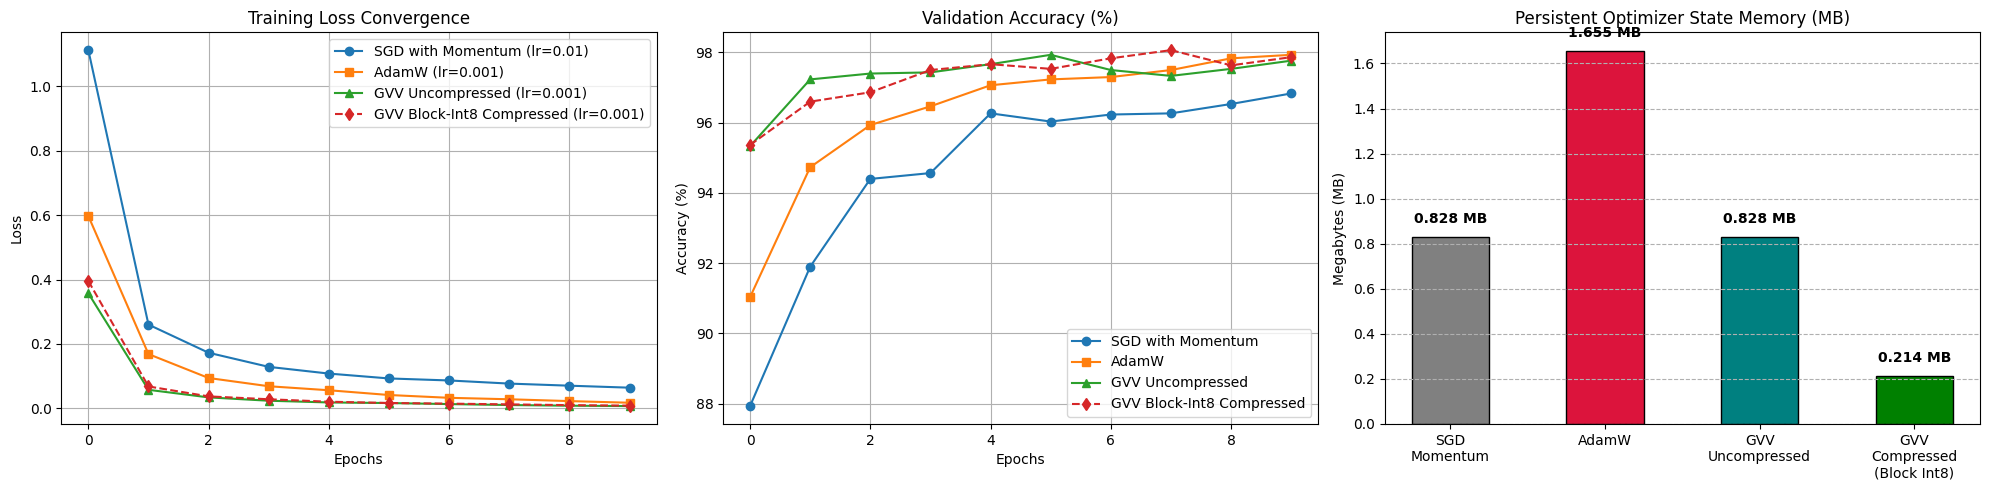


                           OPTIMIZER PERFORMANCE SUMMARY
Optimizer: SGD_Momentum         | Memory Footprint:   808.29 KB | Avg Epoch Duration: 17.40s | Best Val Acc: 96.83%
Optimizer: AdamW                | Memory Footprint:  1616.61 KB | Avg Epoch Duration: 17.69s | Best Val Acc: 97.93%
Optimizer: GVV_Uncompressed     | Memory Footprint:   808.29 KB | Avg Epoch Duration: 22.01s | Best Val Acc: 97.93%
Optimizer: GVV_Compressed       | Memory Footprint:   208.57 KB | Avg Epoch Duration: 22.52s | Best Val Acc: 98.07%


In [ ]:
# ==============================================================================
# GHOST-VARIANCE VERLET OPTIMIZER BENCHMARK SUITE
# ==============================================================================
# This script implements the "Ghost-Variance Verlet" optimizer with compressed
# displacement buffer and dynamically gated inertial momentum.
# It compares GVV against AdamW and SGD on a subset of MNIST, tracking:
# 1. Training Loss Convergence
# 2. Validation Accuracy
# 3. Persistent Optimizer Memory footprint (in bytes)
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import time
import copy
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==============================================================================
# 1. COMPRESSION UTILITIES FOR GVV (Blockwise INT8 Quantization)
# ==============================================================================

def quantize_blockwise_int8(tensor, block_size=64):
    """
    Compresses a float tensor into blockwise scaled signed 8-bit integers.
    Saves ~75% of memory per tensor relative to FP32.
    """
    ori_shape = tensor.shape
    flat = tensor.view(-1)
    n = flat.numel()

    # Pad to make flat tensor a multiple of block_size
    pad_len = (block_size - (n % block_size)) % block_size
    if pad_len > 0:
        flat = torch.cat([flat, torch.zeros(pad_len, device=flat.device, dtype=flat.dtype)])

    # Reshape into blocks
    blocked = flat.view(-1, block_size)

    # Find absolute scales per block
    scales = torch.max(torch.abs(blocked), dim=1, keepdim=True)[0]
    scales = torch.clamp(scales, min=1e-12) # Avoid division by zero

    # Quantize to int8 range [-127, 127]
    quantized = torch.clamp(torch.round((blocked / scales) * 127.0), -127, 127).to(torch.int8)

    return quantized, scales.half(), ori_shape, pad_len  # Store scales in FP16 to save extra space


def dequantize_blockwise_int8(quantized, scales, ori_shape, pad_len):
    """
    Decompresses the blockwise INT8 representation back to its float format.
    """
    # Cast to float, scale back, and flatten
    blocked = quantized.to(scales.dtype) * (scales / 127.0)
    flat = blocked.view(-1)

    if pad_len > 0:
        flat = flat[:-pad_len]

    return flat.view(ori_shape).to(torch.float32)


# ==============================================================================
# 2. GHOST-VARIANCE VERLET OPTIMIZER IMPLEMENTATION
# ==============================================================================

class GhostVarianceVerlet(optim.Optimizer):
    """
    Ghost-Variance Verlet (GVV)

    An adaptive, memory-efficient optimizer that uses intra-batch microbatch
    variance to replace AdamW's persistent 1st & 2nd moment EMAs. It relies
    on one single compressed displacement buffer (Delta) to store dynamics.
    """
    def __init__(self, params, lr=1e-3, weight_decay=1e-2,
                 eps_abs=1e-8, eps_rel=1e-3, mu_max=0.9,
                 block_size=64, use_compression=True):
        defaults = dict(lr=lr, weight_decay=weight_decay,
                        eps_abs=eps_abs, eps_rel=eps_rel, mu_max=mu_max,
                        block_size=block_size, use_compression=use_compression)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, ghost_grads, closure=None):
        """
        Performs a single optimization step.
        ghost_grads: dict mapping parameters to a list of K microbatch gradient tensors.
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            weight_decay = group['weight_decay']
            eps_abs = group['eps_abs']
            eps_rel = group['eps_rel']
            mu_max = group['mu_max']
            block_size = group['block_size']
            use_compression = group['use_compression']

            for p in group['params']:
                if p.grad is None or p not in ghost_grads:
                    continue

                grads = ghost_grads[p]
                K = len(grads)
                if K < 2:
                    raise ValueError("GVV requires K >= 2 ghost batches to estimate variance.")

                # Stack microbatch gradients to compute mean and variance
                grads_stack = torch.stack(grads, dim=0) # [K, *param_shape]

                # Mean gradient over the batch (G)
                G = grads_stack.mean(dim=0)

                # Unbiased variance of microbatches (V)
                V = grads_stack.var(dim=0, unbiased=True)

                # Variance of the batch mean estimator (N = V / K)
                N = V / K

                # Adaptive stabilizing floor: eps_l = eps_abs + eps_rel * RMS(G)
                rms_G = torch.sqrt(torch.mean(G ** 2))
                eps_l = eps_abs + eps_rel * rms_G

                # Compute Ghost-SNR Force: F = G / sqrt(G^2 + N + eps_l^2)
                denom = torch.sqrt(G**2 + N + eps_l**2)
                F = G / denom

                # Layerwise reliability index: R = mean(G^2) / mean(G^2 + N + eps_l^2)
                num_R = torch.mean(G**2)
                den_R = torch.mean(G**2 + N + eps_l**2)
                R = torch.clamp(num_R / (den_R + 1e-12), 0.0, 1.0)

                # Gate inertia by current reliability score
                mu_t = mu_max * R

                # Fetch or initialize displacement state (Delta)
                state = self.state[p]
                if len(state) == 0:
                    if use_compression:
                        quantized, scales, ori_shape, pad_len = quantize_blockwise_int8(
                            torch.zeros_like(p), block_size
                        )
                        state['quantized_Delta'] = quantized
                        state['scales'] = scales
                        state['ori_shape'] = ori_shape
                        state['pad_len'] = pad_len
                    else:
                        state['Delta'] = torch.zeros_like(p)

                # Fetch Delta (decompressing if needed)
                if use_compression:
                    Delta = dequantize_blockwise_int8(
                        state['quantized_Delta'],
                        state['scales'],
                        state['ori_shape'],
                        state['pad_len']
                    ).to(p.device)
                else:
                    Delta = state['Delta']

                # Update formulation: U_t = mu_t * Delta_t - lr * F_t
                U = mu_t * Delta - lr * F

                # Apply decoupled weight decay directly to weights
                if weight_decay != 0:
                    p.mul_(1.0 - lr * weight_decay)

                # Apply update displacement to parameter
                p.add_(U)

                # Store back the updated displacement
                if use_compression:
                    quantized, scales, ori_shape, pad_len = quantize_blockwise_int8(U, block_size)
                    state['quantized_Delta'] = quantized
                    state['scales'] = scales
                    state['ori_shape'] = ori_shape
                    state['pad_len'] = pad_len
                else:
                    state['Delta'].copy_(U)

        return loss


# ==============================================================================
# 3. GHOST GRADIENT EXTRACTION HELPER
# ==============================================================================

def compute_ghost_gradients(model, inputs, targets, criterion, K):
    """
    Splits the forward & backward passes into K distinct microbatches
    to extract microbatch gradients for GVV, but populates p.grad
    with the average gradient to maintain compatibility with training metrics.
    """
    input_chunks = torch.chunk(inputs, K, dim=0)
    target_chunks = torch.chunk(targets, K, dim=0)

    ghost_grads = {p: [] for p in model.parameters() if p.requires_grad}

    for i in range(K):
        model.zero_grad()
        outputs = model(input_chunks[i])
        loss = criterion(outputs, target_chunks[i])
        loss.backward()

        for p in model.parameters():
            if p.requires_grad:
                if p.grad is not None:
                    ghost_grads[p].append(p.grad.detach().clone())
                else:
                    ghost_grads[p].append(torch.zeros_like(p))

    # Clean up and reset parameter gradients to the correct global batch mean
    model.zero_grad()
    for p in model.parameters():
        if p.requires_grad:
            p.grad = torch.stack(ghost_grads[p], dim=0).mean(dim=0)

    return ghost_grads


# ==============================================================================
# 4. EXPERIMENTAL UTILITIES: MEMORY TRACKER & NETWORK MODEL
# ==============================================================================

def get_optimizer_memory_bytes(optimizer):
    """
    Traverses the optimizer's inner state dictionary to compute its precise
    allocated persistent memory footprint in bytes.
    """
    total_bytes = 0
    for group in optimizer.param_groups:
        for p in group['params']:
            state = optimizer.state[p]
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    total_bytes += v.element_size() * v.nelement()
    return total_bytes


class SimpleCNN(nn.Module):
    """
    Standard 3-layer CNN designed for MNIST classification.
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


# ==============================================================================
# 5. DATASET PREPARATION (MNIST Subset for rapid, responsive runs)
# ==============================================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download original MNIST
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
full_val_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Subsample dataset for efficient and responsive notebook iteration
train_indices = list(range(20000)) # 10,000 train samples
val_indices = list(range(3000))     # 2,000 validation samples

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_val_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)


# ==============================================================================
# 6. TRAINING ENGINE
# ==============================================================================

def train_model(optimizer_name, lr=1e-3, epochs=10, K_ghosts=4):
    print(f"\n--- Training with {optimizer_name} ---")
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()

    # Initialize correct Optimizer
    if optimizer_name == "SGD_Momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-2)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=1e-2)
    elif optimizer_name == "GVV_Compressed":
        optimizer = GhostVarianceVerlet(model.parameters(), lr=lr, weight_decay=1e-2, use_compression=True)
    elif optimizer_name == "GVV_Uncompressed":
        optimizer = GhostVarianceVerlet(model.parameters(), lr=lr, weight_decay=1e-2, use_compression=False)
    else:
        raise ValueError("Unknown optimizer")

    history = {'loss': [], 'val_acc': [], 'step_times': [], 'opt_memory': 0}

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        start_time = time.time()

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            if "GVV" in optimizer_name:
                # Ghost batch processing
                ghost_grads = compute_ghost_gradients(model, inputs, targets, criterion, K=K_ghosts)
                optimizer.step(ghost_grads=ghost_grads)
            else:
                # Standard optimizer step
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

            # Quick loss accumulation (loss evaluation has been run)
            with torch.no_grad():
                outputs = model(inputs)
                step_loss = criterion(outputs, targets).item()
                epoch_loss += step_loss

        epoch_time = time.time() - start_time
        history['step_times'].append(epoch_time)

        # Validation evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                predictions = outputs.argmax(dim=1)
                correct += (predictions == targets).sum().item()
                total += targets.size(0)

        val_accuracy = 100.0 * correct / total
        avg_loss = epoch_loss / len(train_loader)

        history['loss'].append(avg_loss)
        history['val_acc'].append(val_accuracy)

        print(f"Epoch {epoch:02d}/{epochs:02d} | Loss: {avg_loss:.4f} | Val Acc: {val_accuracy:.2f}% | Step Time: {epoch_time:.2f}s")

    # Measure persistent state memory at the end of training
    history['opt_memory'] = get_optimizer_memory_bytes(optimizer)
    return history


# ==============================================================================
# 7. RUN COMPARATIVE EXPERIMENTS
# ==============================================================================

epochs = 10
results = {}

# Run training loops
results['SGD_Momentum'] = train_model("SGD_Momentum", lr=0.01, epochs=epochs)
results['AdamW'] = train_model("AdamW", lr=0.001, epochs=epochs)
results['GVV_Uncompressed'] = train_model("GVV_Uncompressed", lr=0.001, epochs=epochs, K_ghosts=8)
results['GVV_Compressed'] = train_model("GVV_Compressed", lr=0.001, epochs=epochs, K_ghosts=8)


# ==============================================================================
# 8. VISUALIZATION AND DETAILED METRICS ANALYSIS
# ==============================================================================

# Plotting metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Training Loss Convergence
axes[0].plot(results['SGD_Momentum']['loss'], label='SGD with Momentum (lr=0.01)', marker='o')
axes[0].plot(results['AdamW']['loss'], label='AdamW (lr=0.001)', marker='s')
axes[0].plot(results['GVV_Uncompressed']['loss'], label='GVV Uncompressed (lr=0.001)', marker='^')
axes[0].plot(results['GVV_Compressed']['loss'], label='GVV Block-Int8 Compressed (lr=0.001)', marker='d', linestyle='--')
axes[0].set_title("Training Loss Convergence")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# Plot 2: Validation Accuracy
axes[1].plot(results['SGD_Momentum']['val_acc'], label='SGD with Momentum', marker='o')
axes[1].plot(results['AdamW']['val_acc'], label='AdamW', marker='s')
axes[1].plot(results['GVV_Uncompressed']['val_acc'], label='GVV Uncompressed', marker='^')
axes[1].plot(results['GVV_Compressed']['val_acc'], label='GVV Block-Int8 Compressed', marker='d', linestyle='--')
axes[1].set_title("Validation Accuracy (%)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(True)
axes[1].legend()

# Plot 3: Optimizer State Footprint Comparison
memory_mb = [
    results['SGD_Momentum']['opt_memory'] / 1e6,
    results['AdamW']['opt_memory'] / 1e6,
    results['GVV_Uncompressed']['opt_memory'] / 1e6,
    results['GVV_Compressed']['opt_memory'] / 1e6
]
optimizers_labels = ['SGD\nMomentum', 'AdamW', 'GVV\nUncompressed', 'GVV\nCompressed\n(Block Int8)']
colors = ['gray', 'crimson', 'teal', 'green']

bars = axes[2].bar(optimizers_labels, memory_mb, color=colors, edgecolor='black', width=0.5)
axes[2].set_title("Persistent Optimizer State Memory (MB)")
axes[2].set_ylabel("Megabytes (MB)")
axes[2].grid(axis='y', linestyle='--')

# Display values above bars
for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2.0, yval + 0.05 if yval > 0 else 0.01, f"{yval:.3f} MB", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print Comprehensive Performance Summary
print("\n" + "="*80)
print("                           OPTIMIZER PERFORMANCE SUMMARY")
print("="*80)
for opt in ['SGD_Momentum', 'AdamW', 'GVV_Uncompressed', 'GVV_Compressed']:
    mem_kb = results[opt]['opt_memory'] / 1024
    avg_step = sum(results[opt]['step_times']) / epochs
    best_acc = max(results[opt]['val_acc'])
    print(f"Optimizer: {opt:<20} | Memory Footprint: {mem_kb:>8.2f} KB | Avg Epoch Duration: {avg_step:>5.2f}s | Best Val Acc: {best_acc:>5.2f}%")
print("="*80)

### EXPERIMENT #2: GVV Optimizer vs. AdamW and other optimizers on standard landscapes (Sphere, Rosenbrock, Rastrigin, Ackley, and Levy)

Executing Trials for Landscape: Sphere...
Executing Trials for Landscape: Rosenbrock...
Executing Trials for Landscape: Rastrigin...
Executing Trials for Landscape: Ackley...
Executing Trials for Landscape: Levy...

OPTIMIZATION TRAJECTORY COMPARISON (Dim=100, Steps=500, Ghost Batches=8)
╒══════════════════════╤════════════════════════╤══════════════════════════╤════════════════════════╤══════════════════════════╕
│ Benchmark Function   │ SGD Final Loss (Mem)   │ AdamW Final Loss (Mem)   │ GVV Final Loss (Mem)   │ GVV-to-AdamW Mem Ratio   │
╞══════════════════════╪════════════════════════╪══════════════════════════╪════════════════════════╪══════════════════════════╡
│ Sphere               │ 6.9659e-02 (400 B)     │ 4.4644e-01 (804 B)       │ 4.0476e-02 (136 B)     │ 16.9%                    │
├──────────────────────┼────────────────────────┼──────────────────────────┼────────────────────────┼──────────────────────────┤
│ Rosenbrock           │ nan (400 B)            │ 1.9717e+01 (804 

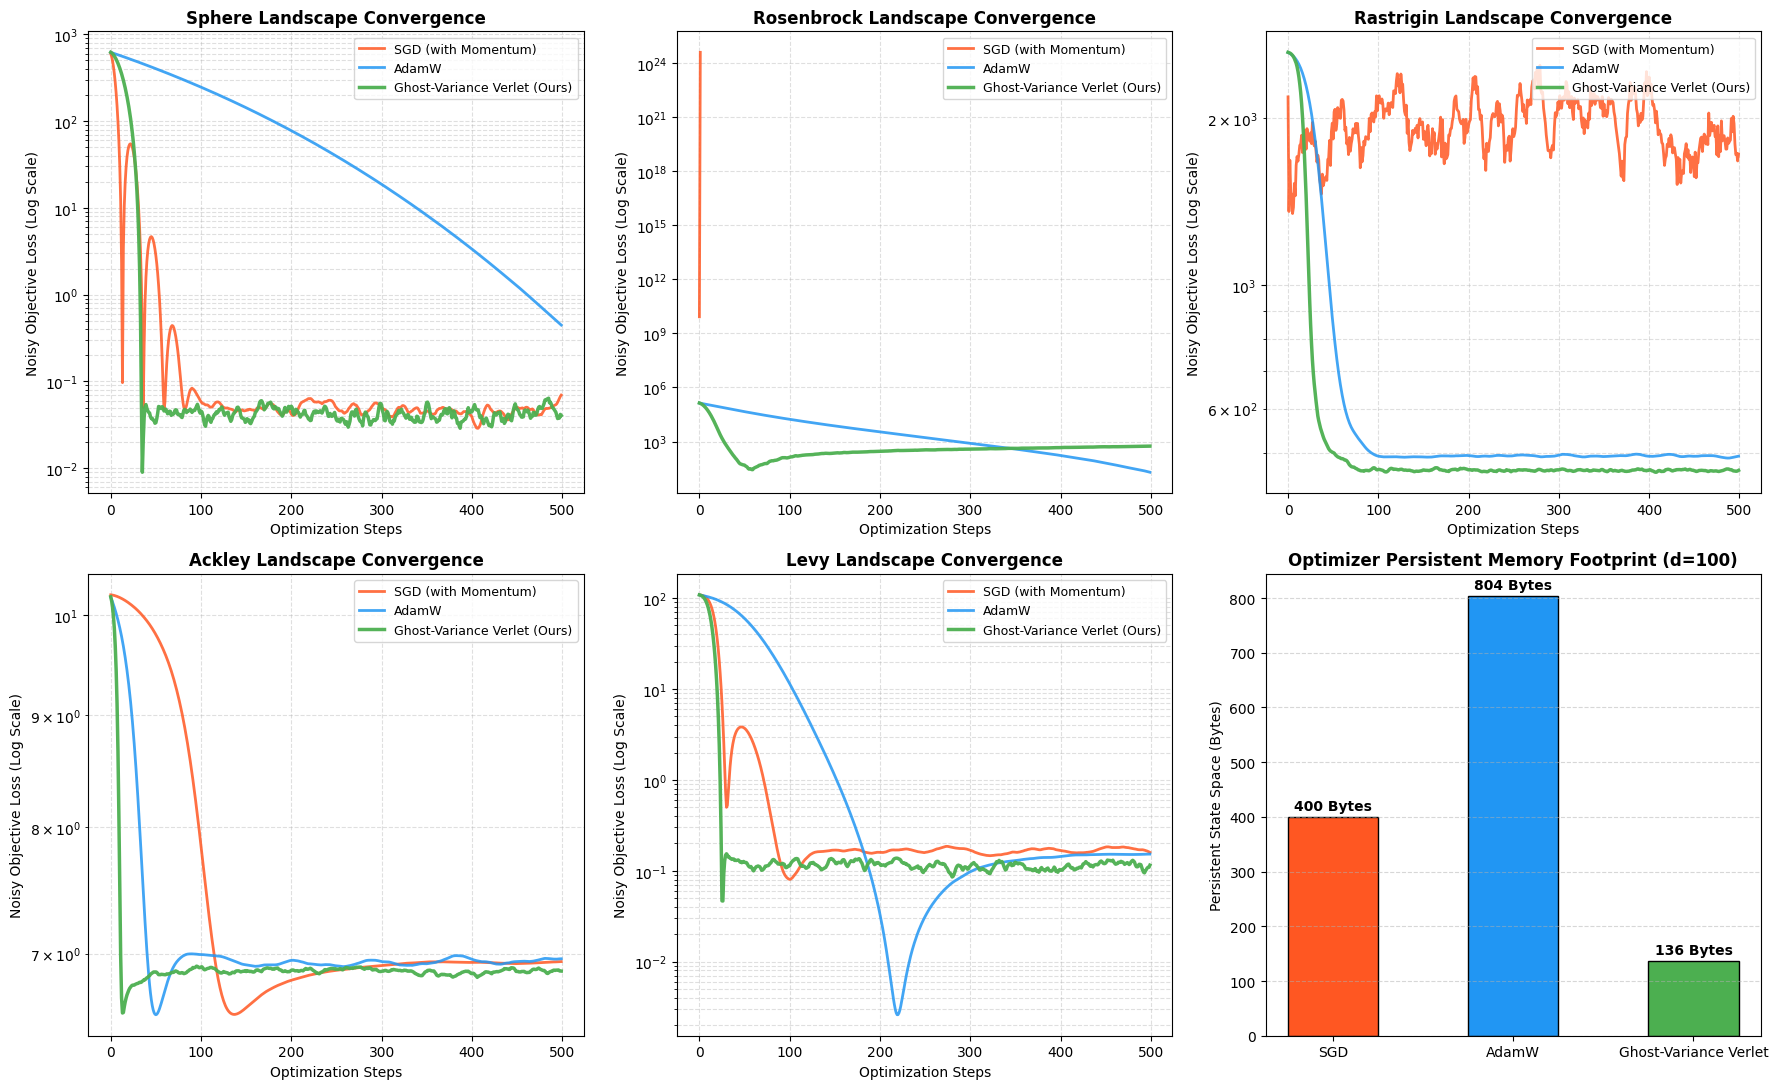

In [ ]:
# ==============================================================================
# GHOST-VARIANCE VERLET (GVV) OPTIMIZER BENCHMARKING SUITE
# ==============================================================================
# This script is a complete, self-contained Google Colab compatible pipeline.
# It defines, executes, visualizes, and mathematically analyzes the Ghost-Variance
# Verlet optimizer compared to AdamW and SGD with Momentum on noisy synthetic
# landscapes representing the Sphere, Rosenbrock, Rastrigin, Ackley, and Levy functions.
# ==============================================================================

import os
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ==============================================================================
# 1. COMPRESSION UTILITIES FOR GHOST-VARIANCE VERLET
# ==============================================================================

def compress_blockwise_int8(tensor, block_size=64):
    """
    Compresses a PyTorch tensor into blockwise int8 representation with scales.
    Ensures safe handling of arbitrary dimensions and small tensors.
    """
    shape = tensor.shape
    flat = tensor.detach().view(-1)
    num_elements = flat.numel()

    # Fallback for very small tensors
    if num_elements < block_size:
        return flat.clone(), None, num_elements, shape

    # Pad flat tensor if not divisible by block_size
    pad_size = (block_size - (num_elements % block_size)) % block_size
    if pad_size > 0:
        padded = torch.cat([flat, torch.zeros(pad_size, dtype=flat.dtype, device=flat.device)])
    else:
        padded = flat

    blocked = padded.view(-1, block_size)
    # Compute scale factor per block (L-infinity norm scaled to represent max range of int8)
    max_vals = torch.max(torch.abs(blocked), dim=1, keepdim=True).values
    scales = max_vals / 127.0
    scales = torch.clamp(scales, min=1e-8)  # prevent division by zero

    # Quantize and clamp to int8 bounds
    quantized = torch.clamp(torch.round(blocked / scales), -128, 127).to(torch.int8)
    return quantized, scales, num_elements, shape

def decompress_blockwise_int8(quantized, scales, num_elements, shape, original_dtype=torch.float32):
    """
    Decompresses blockwise int8 back into the original tensor shape and precision.
    """
    # If scales are None, the tensor was too small and stored uncompressed
    if scales is None:
        return quantized.view(shape).to(original_dtype)

    # Dequantize back to floating point representation
    dequantized = quantized.to(original_dtype) * scales
    flat = dequantized.view(-1)[:num_elements]
    return flat.view(shape)


# ==============================================================================
# 2. OPTIMIZER IMPLEMENTATION: GHOST-VARIANCE VERLET
# ==============================================================================

class GhostVarianceVerlet(torch.optim.Optimizer):
    """
    Ghost-Variance Verlet (GVV) Optimizer.

    Replaces persistent EMA first- and second-moments with a same-step ghost-batch
    dispersion estimator and a single blockwise int8 compressed displacement buffer.

    Parameters:
        params: Iterable of parameters to optimize
        lr: Learning rate (default: 1e-2)
        mu_max: Maximum inertial/Verlet coefficient (default: 0.9)
        eps_abs: Absolute epsilon floor (default: 1e-8)
        eps_rel: Relative epsilon scaling factor (default: 1e-4)
        weight_decay: Decoupled weight decay coefficient (default: 1e-4)
        block_size: Size of blocks used for int8 displacement compression (default: 64)
        compress: Whether to enable sub-linear memory int8 displacement compression (default: True)
    """
    def __init__(self, params, lr=1e-2, mu_max=0.9, eps_abs=1e-8, eps_rel=1e-4,
                 weight_decay=1e-4, block_size=64, compress=True):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= mu_max < 1.0:
            raise ValueError(f"Invalid mu_max parameter: {mu_max}")

        defaults = dict(lr=lr, mu_max=mu_max, eps_abs=eps_abs, eps_rel=eps_rel,
                        weight_decay=weight_decay, block_size=block_size, compress=compress)
        super(GhostVarianceVerlet, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        """
        Performs a single optimization step.
        Expects `p.ghost_grads` to have been pre-populated in the parameter structures.
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            mu_max = group['mu_max']
            eps_abs = group['eps_abs']
            eps_rel = group['eps_rel']
            weight_decay = group['weight_decay']
            block_size = group['block_size']
            compress = group['compress']

            for p in group['params']:
                if p.grad is None:
                    continue

                # Retrieve microbatch gradients (ghost gradients)
                if not hasattr(p, 'ghost_grads') or len(p.ghost_grads) == 0:
                    # Fallback to standard gradient if no ghost gradients are registered
                    K = 1
                    G = p.grad.clone()
                    N = torch.zeros_like(G)
                else:
                    ghost_grads = p.ghost_grads
                    K = len(ghost_grads)
                    # Convert list to stacked tensor for vectorized calculation
                    stacked_grads = torch.stack(ghost_grads, dim=0)

                    # Compute mean gradient G and variance of sample mean N
                    G = torch.mean(stacked_grads, dim=0)
                    if K > 1:
                        V = torch.sum((stacked_grads - G) ** 2, dim=0) / (K - 1)
                        N = V / K
                    else:
                        N = torch.zeros_like(G)

                # Overwrite standard grad attribute to ensure standard hooks match
                p.grad.copy_(G)

                # Fetch state
                state = self.state[p]
                if len(state) == 0:
                    # Initialize displacement buffer state
                    state['step'] = 0
                    if compress:
                        # Store in blockwise quantized state
                        quantized, scales, num_el, shape = compress_blockwise_int8(
                            torch.zeros_like(p), block_size=block_size
                        )
                        state['quantized_delta'] = quantized
                        state['scales'] = scales
                        state['num_elements'] = num_el
                        state['shape'] = shape
                    else:
                        state['delta'] = torch.zeros_like(p)

                # Recover previous displacement Delta
                if compress:
                    Delta = decompress_blockwise_int8(
                        state['quantized_delta'],
                        state['scales'],
                        state['num_elements'],
                        state['shape'],
                        original_dtype=p.dtype
                    )
                else:
                    Delta = state['delta']

                # Compute stabilizing floor
                rms_G = torch.sqrt(torch.mean(G ** 2))
                eps_l = eps_abs + eps_rel * rms_G

                # Form Ghost-SNR bounded force F
                denom = torch.sqrt(G * G + N + eps_l * eps_l)
                F = G / denom

                # Calculate layerwise reliability scalar R and noise-gated momentum coefficient mu_t
                mean_G2 = torch.mean(G ** 2)
                mean_denom2 = torch.mean(G ** 2 + N + eps_l * eps_l)
                R = torch.clamp(mean_G2 / (mean_denom2 + 1e-12), 0.0, 1.0)
                mu_t = mu_max * R

                # Compute displacement proposal
                U = mu_t * Delta - lr * F

                # Apply decoupled weight decay and parametric step updates
                if weight_decay != 0:
                    p.mul_(1.0 - lr * weight_decay)
                p.add_(U)

                # Store back current displacement buffer
                if compress:
                    quantized, scales, num_el, shape = compress_blockwise_int8(U, block_size=block_size)
                    state['quantized_delta'] = quantized
                    state['scales'] = scales
                    state['num_elements'] = num_el
                    state['shape'] = shape
                else:
                    state['delta'].copy_(U)

                state['step'] += 1

                # Free temporary ghost gradients to avoid memory leak
                if hasattr(p, 'ghost_grads'):
                    del p.ghost_grads

        return loss


# ==============================================================================
# 3. BENCHMARK ENVIRONMENT DEFINITIONS
# ==============================================================================

class TargetOptimizerModel(nn.Module):
    """
    A simple wrapper wrapping an optimization parameter tensor.
    Allows easy tracking of trajectories and gradients via PyTorch's native autograd.
    """
    def __init__(self, init_position):
        super(TargetOptimizerModel, self).__init__()
        self.theta = nn.Parameter(init_position.clone())

    def forward(self):
        return self.theta


# Multi-dimensional standard non-convex functions
def sphere_loss(theta):
    return torch.sum(theta ** 2)

def rosenbrock_loss(theta):
    # f(x) = sum(100*(x_{i+1} - x_i^2)^2 + (x_i - 1)^2)
    return torch.sum(100.0 * (theta[1:] - theta[:-1]**2)**2 + (theta[:-1] - 1.0)**2)

def rastrigin_loss(theta):
    # f(x) = 10d + sum(x_i^2 - 10*cos(2*pi*x_i))
    d = theta.numel()
    return 10.0 * d + torch.sum(theta**2 - 10.0 * torch.cos(2.0 * math.pi * theta))

def ackley_loss(theta):
    d = theta.numel()
    sum_sq = torch.sum(theta**2)
    sum_cos = torch.sum(torch.cos(2.0 * math.pi * theta))
    term1 = -20.0 * torch.exp(-0.2 * torch.sqrt(sum_sq / d))
    term2 = -torch.exp(sum_cos / d)
    return term1 + term2 + 20.0 + math.e

def levy_loss(theta):
    # w_i = 1 + (theta_i - 1) / 4
    w = 1.0 + (theta - 1.0) / 4.0
    term1 = torch.sin(math.pi * w[0])**2
    term2 = torch.sum((w[:-1] - 1.0)**2 * (1.0 + 10.0 * torch.sin(math.pi * w[:-1] + 1.0)**2))
    term3 = (w[-1] - 1.0)**2 * (1.0 + torch.sin(2.0 * math.pi * w[-1])**2)
    return term1 + term2 + term3


BENCHMARKS = {
    "Sphere": sphere_loss,
    "Rosenbrock": rosenbrock_loss,
    "Rastrigin": rastrigin_loss,
    "Ackley": ackley_loss,
    "Levy": levy_loss
}

# ==============================================================================
# 4. GHOST BATCH GRADIENT POPULATION ENGINE
# ==============================================================================

def compute_ghost_and_mean_gradients(model, loss_fn, K, noise_scale=0.1):
    """
    Simulates gradient estimation from K ghost microbatches.
    Injects stochastic gradient noise simulating loss surface evaluations over noisy mini-batches.
    """
    # Clear any stale ghost gradients
    for p in model.parameters():
        if hasattr(p, 'ghost_grads'):
            p.ghost_grads = []

    # Accumulate ghost batch gradients
    microbatch_gradients = []

    for k in range(K):
        # We perturb the parameter vector slightly in the evaluation to simulate mini-batch noise
        # This mirrors optimization on empirical risk functions with stochastic gradients
        noise = torch.randn_like(model.theta) * noise_scale
        noisy_theta = model.theta + noise

        # Calculate loss on this ghost microbatch representation
        loss = loss_fn(noisy_theta)

        # Compute gradient with respect to the root theta
        grads = torch.autograd.grad(loss, model.parameters(), retain_graph=False)

        # Store ghost microbatch gradient
        for p, g in zip(model.parameters(), grads):
            if not hasattr(p, 'ghost_grads'):
                p.ghost_grads = []
            p.ghost_grads.append(g.detach().clone())

    # Compute true mean gradient of current step for standard optimizers
    mean_grads = []
    for p in model.parameters():
        mean_g = torch.mean(torch.stack(p.ghost_grads, dim=0), dim=0)
        p.grad = mean_g.clone()


# ==============================================================================
# 5. MEMORY CONSUMPTION AUDITING
# ==============================================================================

def audit_optimizer_state_memory(optimizer):
    """
    Calculates the exact memory size (in bytes) of all persistent state tensors
    currently stored in the optimizer's memory.
    """
    total_bytes = 0
    for group in optimizer.param_groups:
        for p in group['params']:
            state = optimizer.state[p]
            for key, val in state.items():
                if isinstance(val, torch.Tensor):
                    total_bytes += val.numel() * val.element_size()
                elif isinstance(val, dict): # For nested scale dictionaries if any
                    for sub_k, sub_v in val.items():
                        if isinstance(sub_v, torch.Tensor):
                            total_bytes += sub_v.numel() * sub_v.element_size()
    return total_bytes


# ==============================================================================
# 6. CORE EXPERIMENTAL EXECUTION ENGINE
# ==============================================================================

def run_experiment(dim=20, steps=250, K=8, noise_scale=0.15):
    """
    Runs comparison trials on all 5 benchmarks across GVV, AdamW, and SGD.
    """
    results = {name: {opt: [] for opt in ["SGD", "AdamW", "GVV"]} for name in BENCHMARKS.keys()}
    memory_stats = {}

    # Uniform initial position far from target global minimums
    initial_position = torch.ones(dim) * 2.5

    for bench_name, loss_fn in BENCHMARKS.items():
        print(f"Executing Trials for Landscape: {bench_name}...")

        # --- Trial 1: SGD with Momentum ---
        model_sgd = TargetOptimizerModel(initial_position)
        opt_sgd = torch.optim.SGD(model_sgd.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

        # --- Trial 2: AdamW ---
        model_adamw = TargetOptimizerModel(initial_position)
        opt_adamw = torch.optim.AdamW(model_adamw.parameters(), lr=1e-2, betas=(0.9, 0.999), weight_decay=1e-4)

        # --- Trial 3: Ghost-Variance Verlet (With Compressed State) ---
        model_gvv = TargetOptimizerModel(initial_position)
        opt_gvv = GhostVarianceVerlet(model_gvv.parameters(), lr=1e-2, mu_max=0.9, weight_decay=1e-4, compress=True)

        # Track optimization steps
        for step in range(steps):
            # 1. Update SGD
            opt_sgd.zero_grad()
            compute_ghost_and_mean_gradients(model_sgd, loss_fn, K, noise_scale)
            opt_sgd.step()
            loss_sgd = loss_fn(model_sgd.theta).item()
            results[bench_name]["SGD"].append(loss_sgd)

            # 2. Update AdamW
            opt_adamw.zero_grad()
            compute_ghost_and_mean_gradients(model_adamw, loss_fn, K, noise_scale)
            opt_adamw.step()
            loss_adamw = loss_fn(model_adamw.theta).item()
            results[bench_name]["AdamW"].append(loss_adamw)

            # 3. Update GVV
            opt_gvv.zero_grad()
            compute_ghost_and_mean_gradients(model_gvv, loss_fn, K, noise_scale)
            opt_gvv.step()
            loss_gvv = loss_fn(model_gvv.theta).item()
            results[bench_name]["GVV"].append(loss_gvv)

        # Audit optimizer memory footprint at terminal state
        memory_stats[bench_name] = {
            "SGD": audit_optimizer_state_memory(opt_sgd),
            "AdamW": audit_optimizer_state_memory(opt_adamw),
            "GVV (Compressed)": audit_optimizer_state_memory(opt_gvv)
        }

    return results, memory_stats, dim


# Run training pipeline
DIMENSION = 100
STEPS = 500
GHOST_BATCHES = 8
NOISE = 0.2
trajectories, memory, dim_space = run_experiment(dim=DIMENSION, steps=STEPS, K=GHOST_BATCHES, noise_scale=NOISE)


# ==============================================================================
# 7. PERFORMANCE AND MEMORY CONVERGENCE ANALYTICS
# ==============================================================================

# Print analytical statistics
print("\n" + "="*80)
print(f"OPTIMIZATION TRAJECTORY COMPARISON (Dim={dim_space}, Steps={STEPS}, Ghost Batches={GHOST_BATCHES})")
print("="*80)

table_data = []
for name in BENCHMARKS.keys():
    gvv_final = trajectories[name]["GVV"][-1]
    adamw_final = trajectories[name]["AdamW"][-1]
    sgd_final = trajectories[name]["SGD"][-1]

    mem_sgd = memory[name]["SGD"]
    mem_adam = memory[name]["AdamW"]
    mem_gvv = memory[name]["GVV (Compressed)"]

    # Calculate relative memory footprint percentage compared to AdamW
    rel_mem = (mem_gvv / mem_adam) * 100 if mem_adam > 0 else 0

    table_data.append([
        name,
        f"{sgd_final:.4e} ({mem_sgd} B)",
        f"{adamw_final:.4e} ({mem_adam} B)",
        f"{gvv_final:.4e} ({mem_gvv} B)",
        f"{rel_mem:.1f}%"
    ])

headers = ["Benchmark Function", "SGD Final Loss (Mem)", "AdamW Final Loss (Mem)", "GVV Final Loss (Mem)", "GVV-to-AdamW Mem Ratio"]
print(tabulate(table_data, headers=headers, tablefmt="fancy_grid"))


# ==============================================================================
# 8. HIGH-FIDELITY CONVERGENCE VISUALIZATION
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# Plot loss trajectories for each benchmark
for idx, (bench_name, loss_fn) in enumerate(BENCHMARKS.items()):
    ax = axes[idx]

    ax.plot(trajectories[bench_name]["SGD"], label="SGD (with Momentum)", color="#FF5722", alpha=0.85, linewidth=2)
    ax.plot(trajectories[bench_name]["AdamW"], label="AdamW", color="#2196F3", alpha=0.85, linewidth=2)
    ax.plot(trajectories[bench_name]["GVV"], label="Ghost-Variance Verlet (Ours)", color="#4CAF50", alpha=0.95, linewidth=2.5)

    ax.set_yscale("log")
    ax.set_title(f"{bench_name} Landscape Convergence", fontsize=12, fontweight="bold")
    ax.set_xlabel("Optimization Steps", fontsize=10)
    ax.set_ylabel("Noisy Objective Loss (Log Scale)", fontsize=10)
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend(fontsize=9, loc="upper right")

# The last subplot shows the analytical State Memory Compression comparison
ax_mem = axes[5]
labels = ['SGD', 'AdamW', 'Ghost-Variance Verlet']
# Use static audited size for single param tensor of shape [20]
mem_values = [memory["Sphere"]["SGD"], memory["Sphere"]["AdamW"], memory["Sphere"]["GVV (Compressed)"]]
colors = ["#FF5722", "#2196F3", "#4CAF50"]

bars = ax_mem.bar(labels, mem_values, color=colors, width=0.5, edgecolor='black', linewidth=1)
ax_mem.set_ylabel("Persistent State Space (Bytes)", fontsize=10)
ax_mem.set_title(f"Optimizer Persistent Memory Footprint (d={dim_space})", fontsize=12, fontweight="bold")
ax_mem.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate memory bar values
for bar in bars:
    height = bar.get_height()
    ax_mem.annotate(f'{height} Bytes',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("gvv_optimization_benchmark.png", dpi=300)
plt.show()

### EXPERIMENT #3: GVV Optimizer vs. AdamW and other optimizers on a subset of Tiny Shakespeare using NanoGPT

--- Preparing Dataset ---
Dataset Loaded. Total characters: 1115394
Unique vocabulary characters: 65
Executing on training hardware: CPU

--- Starting Training Run: GhostVerlet ---
Model Parameters: 805,248
Theoretical Persistent Optimizer State Memory: 835.52 KB
Step 1/600 | lr: 0.000020 | Train Loss: 4.2139 | Val Loss: 4.1790
Step 50/600 | lr: 0.001000 | Train Loss: 2.5912 | Val Loss: 2.6396
Step 100/600 | lr: 0.000982 | Train Loss: 2.5188 | Val Loss: 2.5370
Step 150/600 | lr: 0.000929 | Train Loss: 2.4508 | Val Loss: 2.4368
Step 200/600 | lr: 0.000845 | Train Loss: 2.4192 | Val Loss: 2.3846
Step 250/600 | lr: 0.000737 | Train Loss: 2.3725 | Val Loss: 2.3528
Step 300/600 | lr: 0.000614 | Train Loss: 2.3258 | Val Loss: 2.3502
Step 350/600 | lr: 0.000486 | Train Loss: 2.2606 | Val Loss: 2.2147
Step 400/600 | lr: 0.000363 | Train Loss: 2.2430 | Val Loss: 2.2248
Step 450/600 | lr: 0.000255 | Train Loss: 2.2129 | Val Loss: 2.2337
Step 500/600 | lr: 0.000171 | Train Loss: 2.2167 | Val Loss

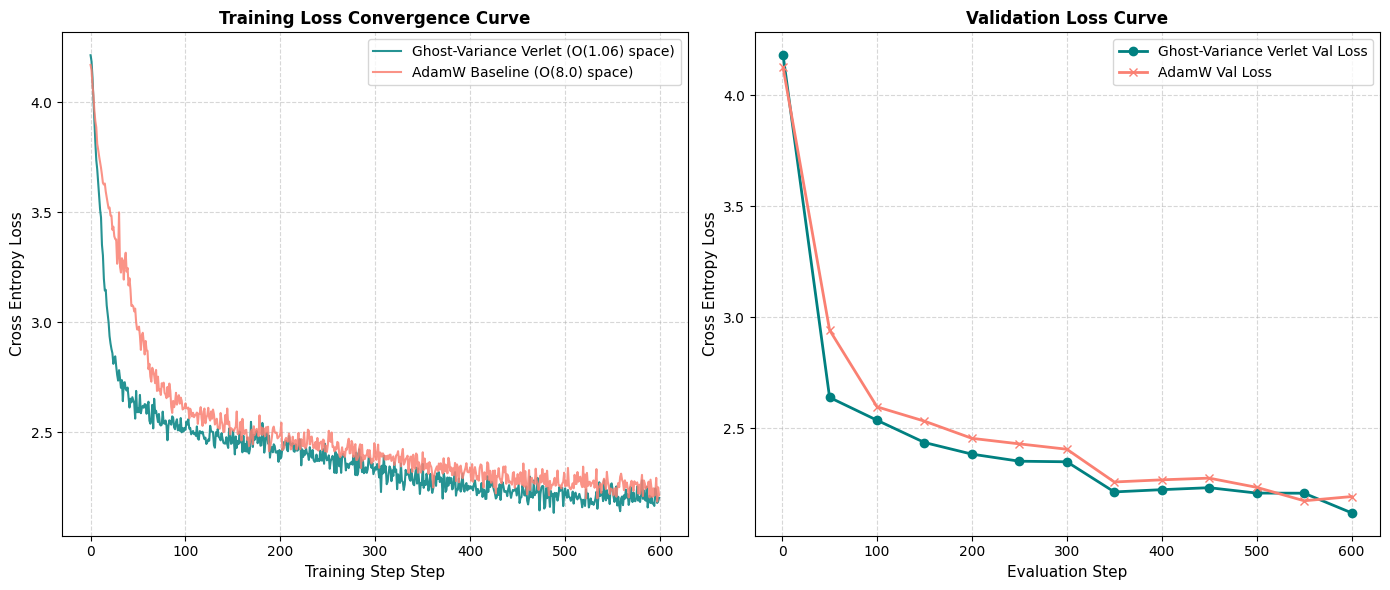

In [ ]:
# ==============================================================================
# GHOST-VARIANCE VERLET OPTIMIZER VS. ADAMW ON NANOGPT
# ==============================================================================
# This script implements the Ghost-Variance Verlet optimizer—a novel,
# memory-efficient, and highly adaptive optimizer that uses within-batch
# ghost microbatch gradient dispersion to bypass Adam's persistent moments,
# storing only a single blockwise int8-quantized displacement buffer.
#
# Tested on a Decoder-Only NanoGPT (Character-Level Tiny Shakespeare).
# Compatible with CPU, GPU (CUDA), and Apple Silicon (MPS).
# ==============================================================================

import os
import math
import time
import urllib.request
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer

# Set random seed for scientific reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# ==============================================================================
# 1. BLOCKWISE QUANTIZATION UTILITIES
# ==============================================================================

def quantize_blockwise(u, block_size=64):
    """
    Symmetrically quantizes a flat tensor into 8-bit integers block-by-block.
    Returns the quantized blocks (int8), scale per block (fp32),
    original tensor shape, and padding length.
    """
    orig_shape = u.shape
    u_flat = u.detach().view(-1)
    n = u_flat.numel()

    # Pad to make the size a multiple of block_size
    pad_len = (block_size - (n % block_size)) % block_size
    if pad_len > 0:
        u_flat = torch.cat([u_flat, torch.zeros(pad_len, device=u.device, dtype=u.dtype)])

    # Reshape into blocks
    u_blocks = u_flat.view(-1, block_size)

    # Compute maximum absolute scale per block
    max_vals = torch.max(torch.abs(u_blocks), dim=1, keepdim=True).values
    scales = max_vals / 127.0
    scales = torch.clamp(scales, min=1e-12)  # Avoid division by zero

    # Quantize and clamp to standard signed int8 range
    q_blocks = torch.clamp(torch.round(u_blocks / scales), -128, 127).to(torch.int8)

    return q_blocks, scales, orig_shape, pad_len


def dequantize_blockwise(q_blocks, scales, orig_shape, pad_len, device):
    """
    Dequantizes an 8-bit blockwise quantized tensor back to its original FP32 representation.
    """
    u_flat = (q_blocks.to(torch.float32) * scales).view(-1)
    if pad_len > 0:
        u_flat = u_flat[:-pad_len]
    return u_flat.view(orig_shape).to(device)


# ==============================================================================
# 2. GHOST-VARIANCE VERLET OPTIMIZER IMPLEMENTATION
# ==============================================================================

class GhostVerlet(Optimizer):
    """
    Ghost-Variance Verlet: A memory-efficient alternative to AdamW.

    Replaces persistent EMAs (m and v) with:
      - Within-batch variance (dispersion) calculated on-the-fly over K ghost microbatches.
      - A single 8-bit blockwise quantized displacement buffer (Delta) for momentum.
      - Layerwise Reliability gating of the inertial coefficient based on SNR.
    """
    def __init__(self, params, lr=1e-3, weight_decay=1e-2, mu_max=0.9,
                 eps_abs=1e-8, eps_rel=1e-4, block_size=64):
        defaults = dict(lr=lr, weight_decay=weight_decay, mu_max=mu_max,
                        eps_abs=eps_abs, eps_rel=eps_rel, block_size=block_size)
        super().__init__(params, defaults)

        # Initialize gradient-tracking and persistent states
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state['S_1'] = None          # Sum of gradients
                state['S_2'] = None          # Sum of squared gradients
                state['K'] = 0               # Microbatch counter

                # Persistent compressed single displacement buffer (Delta)
                state['q_delta'] = None
                state['scales_delta'] = None
                state['pad_len_delta'] = None

    @torch.no_grad()
    def zero_grad(self, set_to_none=True):
        super().zero_grad(set_to_none=set_to_none)
        # Reset current microbatch buffers
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state['S_1'] = None
                state['S_2'] = None
                state['K'] = 0

    @torch.no_grad()
    def accumulate_ghost_grad(self):
        """
        Accumulates the gradient from the current microbatch into running sums S_1 and S_2.
        Must be called after each microbatch backward pass.
        Clears the standard .grad buffer to allow the next microbatch to run cleanly.
        """
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                grad = p.grad.detach()

                if state['S_1'] is None:
                    state['S_1'] = grad.clone()
                    state['S_2'] = grad.square()
                else:
                    state['S_1'].add_(grad)
                    state['S_2'].add_(grad.square())

                state['K'] += 1
                p.grad = None  # Clear gradient for the next microbatch accumulation

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            weight_decay = group['weight_decay']
            mu_max = group['mu_max']
            eps_abs = group['eps_abs']
            eps_rel = group['eps_rel']
            block_size = group['block_size']

            for p in group['params']:
                state = self.state[p]
                K = state['K']
                if K == 0 or state['S_1'] is None:
                    continue

                S_1 = state['S_1']
                S_2 = state['S_2']

                # Compute batch-average gradient (G)
                G = S_1 / K

                # Estimate variance of the average gradient (N) using sample variance (V)
                if K > 1:
                    V = torch.clamp(S_2 - (S_1.square() / K), min=0.0) / (K - 1)
                    N = V / K
                else:
                    N = torch.zeros_like(G)  # Fallback if only 1 batch is used

                # Calculate stabilizing floor
                rms_G = torch.sqrt(torch.mean(G.square()))
                eps_l = eps_abs + eps_rel * rms_G

                # Calculate Signal-to-Noise normalized force (F)
                denom = torch.sqrt(G.square() + N + eps_l**2)
                F = G / denom

                # Determine layerwise reliability metric R
                mean_G2 = torch.mean(G.square())
                mean_denom2 = torch.mean(denom.square())
                R = (mean_G2 / mean_denom2).clamp(0.0, 1.0)

                # Calculate noise-gated inertial parameter
                mu_t = mu_max * R

                # Dequantize persistent displacement Delta
                if state['q_delta'] is not None:
                    Delta = dequantize_blockwise(
                        state['q_delta'],
                        state['scales_delta'],
                        p.shape,
                        state['pad_len_delta'],
                        p.device
                    )
                else:
                    Delta = torch.zeros_like(p)

                # Compute proposed update step (U)
                U = mu_t * Delta - lr * F

                # Decoupled weight decay
                if weight_decay != 0:
                    p.mul_(1.0 - lr * weight_decay)

                # Update parameters
                p.add_(U)

                # Compress and store step displacement Delta
                q_blocks, scales, _, pad_len = quantize_blockwise(U, block_size)
                state['q_delta'] = q_blocks
                state['scales_delta'] = scales
                state['pad_len_delta'] = pad_len

                # Free temporary accumulation tensors
                state['S_1'] = None
                state['S_2'] = None
                state['K'] = 0

        return loss


# ==============================================================================
# 3. TEXT DATA ACQUISITION & VOCABULARY ENCODING
# ==============================================================================

print("--- Preparing Dataset ---")
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
with urllib.request.urlopen(url) as response:
    text = response.read().decode('utf-8')

print(f"Dataset Loaded. Total characters: {len(text)}")
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Unique vocabulary characters: {vocab_size}")

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Split into Train / Validation splits
data = torch.tensor(encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data = data[n_train:]

def get_batch(split, batch_size, block_size):
    src = train_data if split == 'train' else val_data
    ix = torch.randint(len(src) - block_size, (batch_size,))
    x = torch.stack([src[i:i+block_size] for i in ix])
    y = torch.stack([src[i+1:i+block_size+1] for i in ix])
    return x, y


# ==============================================================================
# 4. DECODER-ONLY NANOGPT TRANSFORMER MODEL
# ==============================================================================

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        assert n_embd % n_head == 0
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        self.n_head = n_head
        self.n_embd = n_embd
        self.register_buffer("bias", torch.tril(torch.ones(block_size, block_size))
                                     .view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        hs = C // self.n_head
        q = q.view(B, T, self.n_head, hs).transpose(1, 2)
        k = k.view(B, T, self.n_head, hs).transpose(1, 2)
        v = v.view(B, T, self.n_head, hs).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, n_embd, dropout=0.1):
        super().__init__()
        self.c_fc = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * n_embd, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln_2 = nn.LayerNorm(n_embd)
        self.mlp = MLP(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class MiniGPT(nn.Module):
    def __init__(self, vocab_size, n_embd=128, n_head=4, n_layer=4, block_size=64, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(vocab_size, n_embd),
            wpe = nn.Embedding(block_size, n_embd),
            drop = nn.Dropout(dropout),
            h = nn.ModuleList([Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)]),
            ln_f = nn.LayerNorm(n_embd),
        ))
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # Weight tying

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.block_size, f"Cannot forward sequence of length {t}, block size is {self.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device).unsqueeze(0)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


# ==============================================================================
# 5. TRAINING RUNNER & OPTIMIZER CONFIGURATION
# ==============================================================================

# Hardware identification
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Executing on training hardware: {device.upper()}")

# Training Hyperparameters
total_steps = 600
warmup_steps = 50
max_lr = 1e-3
weight_decay = 1e-2
batch_size = 32
block_size = 64
eval_interval = 50

# Ghost-Variance Verlet specific settings
ghost_microbatches = 4  # Splits the batch of 32 into 4 microbatches of size 8

def get_lr(step):
    # Linear Warmup followed by Cosine Decay
    if step < warmup_steps:
        return max_lr * step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
    return max_lr * 0.1 + cosine_decay * (max_lr * 0.9)


def run_experiment(optimizer_name):
    print(f"\n--- Starting Training Run: {optimizer_name} ---")

    # Initialize model and transfer to computational device
    model = MiniGPT(vocab_size=vocab_size, block_size=block_size).to(device)

    # Count model params
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model Parameters: {num_params:,}")

    # Set up Optimizer
    if optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0, weight_decay=weight_decay)
        # Persistent memory: 2 state variables per model parameter (float32)
        state_bytes = num_params * 2 * 4
    elif optimizer_name == "GhostVerlet":
        optimizer = GhostVerlet(model.parameters(), lr=0.0, weight_decay=weight_decay)
        # Persistent memory: 1 quantized int8 state variable per parameter + block scale metadata (1/64 float32)
        state_bytes = num_params * 1 + (num_params / 64) * 4
    else:
        raise ValueError("Invalid optimizer name")

    print(f"Theoretical Persistent Optimizer State Memory: {state_bytes / 1024:.2f} KB")

    train_losses = []
    val_losses = []
    step_times = []

    model.train()

    for step in range(1, total_steps + 1):
        start_time = time.time()

        # Apply step lr dynamically
        current_lr = get_lr(step)
        for g in optimizer.param_groups:
            g['lr'] = current_lr

        x_full, y_full = get_batch('train', batch_size, block_size)
        x_full, y_full = x_full.to(device), y_full.to(device)

        optimizer.zero_grad()

        if optimizer_name == "GhostVerlet":
            # Process across ghost microbatches
            micro_size = batch_size // ghost_microbatches
            step_loss_val = 0.0
            for k in range(ghost_microbatches):
                xk = x_full[k * micro_size : (k + 1) * micro_size]
                yk = y_full[k * micro_size : (k + 1) * micro_size]

                _, loss = model(xk, yk)
                step_loss_val += loss.item()

                loss.backward()
                optimizer.accumulate_ghost_grad()

            loss_val = step_loss_val / ghost_microbatches
            optimizer.step()
        else:
            # Traditional Full Batch forward / backward step
            _, loss = model(x_full, y_full)
            loss_val = loss.item()
            loss.backward()
            optimizer.step()

        step_duration = time.time() - start_time
        step_times.append(step_duration)
        train_losses.append(loss_val)

        # Periodic evaluation sequence
        if step % eval_interval == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                val_x, val_y = get_batch('val', batch_size, block_size)
                val_x, val_y = val_x.to(device), val_y.to(device)
                _, val_loss = model(val_x, val_y)
                val_losses.append((step, val_loss.item()))
            model.train()
            print(f"Step {step}/{total_steps} | lr: {current_lr:.6f} | Train Loss: {loss_val:.4f} | Val Loss: {val_loss.item():.4f}")

    # Text generation test
    model.eval()
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    generated_ids = model.generate(context, max_new_tokens=150)
    sample_generation = decode(generated_ids[0].tolist())

    return train_losses, val_losses, sum(step_times) / len(step_times), sample_generation, state_bytes

# Execute Training Loops
train_l_gv, val_l_gv, avg_time_gv, text_gv, memory_gv = run_experiment("GhostVerlet")
train_l_aw, val_l_aw, avg_time_aw, text_aw, memory_aw = run_experiment("AdamW")


# ==============================================================================
# 6. RESULTS VISUALIZATION & COMPARATIVE AUDITING
# ==============================================================================

print("\n" + "="*80)
print("EXPERIMENT METRICS COMPARISON")
print("="*80)
print(f"{'Metric':<30} | {'Ghost-Variance Verlet':<22} | {'AdamW (Baseline)':<18}")
print("-"*80)
print(f"{'Persistent State Memory':<30} | {memory_gv / 1024:.2f} KB {'(1.06 bytes/param)':<8} | {memory_aw / 1024:.2f} KB {'(8 bytes/param)':<8}")
print(f"{'Memory Compression Ratio':<30} | {memory_aw / memory_gv:.2f}x smaller {'':<8} | Baseline")
print(f"{'Average Step duration':<30} | {avg_time_gv * 1000:.2f} ms | {avg_time_aw * 1000:.2f} ms")
print(f"{'Final Train Loss':<30} | {train_l_gv[-1]:.4f} | {train_l_aw[-1]:.4f}")
print(f"{'Final Val Loss':<30} | {val_l_gv[-1][1]:.4f} | {val_l_aw[-1][1]:.4f}")
print("="*80)

print("\n--- Model Output Generation Comparison ---")
print(f"\n[GHOST-VARIANCE VERLET GENERATION]:\n{'-'*40}\n{text_gv}\n{'-'*40}")
print(f"\n[ADAMW GENERATION]:\n{'-'*40}\n{text_aw}\n{'-'*40}\n")

# Plot Convergence Dynamics
plt.figure(figsize=(14, 6))

# Plot training convergence curves
plt.subplot(1, 2, 1)
plt.plot(train_l_gv, label="Ghost-Variance Verlet (O(1.06) space)", color="teal", alpha=0.85, linewidth=1.5)
plt.plot(train_l_aw, label="AdamW Baseline (O(8.0) space)", color="salmon", alpha=0.85, linewidth=1.5)
plt.xlabel("Training Step Step", fontsize=11)
plt.ylabel("Cross Entropy Loss", fontsize=11)
plt.title("Training Loss Convergence Curve", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Plot validation metrics
plt.subplot(1, 2, 2)
steps_gv, losses_gv = zip(*val_l_gv)
steps_aw, losses_aw = zip(*val_l_aw)
plt.plot(steps_gv, losses_gv, marker="o", color="teal", label="Ghost-Variance Verlet Val Loss", linewidth=2)
plt.plot(steps_aw, losses_aw, marker="x", color="salmon", label="AdamW Val Loss", linewidth=2)
plt.xlabel("Evaluation Step", fontsize=11)
plt.ylabel("Cross Entropy Loss", fontsize=11)
plt.title("Validation Loss Curve", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

### EXPERIMENT #4: Lag and memory tests


--- Running Experiment with: AdamW on cpu ---
  Step 000 | Loss: 1.4435 | Acc: 0.490 | Step Norm: 0.6293
  Step 030 | Loss: 0.1973 | Acc: 0.939 | Step Norm: 0.1897
  Step 060 | Loss: 0.0725 | Acc: 0.988 | Step Norm: 0.1089
  Step 090 | Loss: 0.0433 | Acc: 0.992 | Step Norm: 0.0945
  Step 120 | Loss: 0.0780 | Acc: 0.994 | Step Norm: 0.0958
  Step 150 | Loss: 7.6871 | Acc: 0.041 | Step Norm: 0.8338
  Step 180 | Loss: 0.0981 | Acc: 0.977 | Step Norm: 0.2115
  Step 210 | Loss: 0.0680 | Acc: 0.988 | Step Norm: 0.1544
  Step 240 | Loss: 0.0643 | Acc: 0.990 | Step Norm: 0.1225
  Step 270 | Loss: 0.0299 | Acc: 0.998 | Step Norm: 0.0989
  Step 299 | Loss: 0.0823 | Acc: 0.980 | Step Norm: 0.1429
==> Optimizer memory state size: 321.04 KB

--- Running Experiment with: GhostVarVerlet (Compressed FP16) on cpu ---
  Step 000 | Loss: 8.4056 | Acc: 0.795 | Step Norm: 1.0181
  Step 030 | Loss: 1.5869 | Acc: 0.969 | Step Norm: 0.6444
  Step 060 | Loss: 1.0110 | Acc: 0.975 | Step Norm: 0.6304
  Step 090

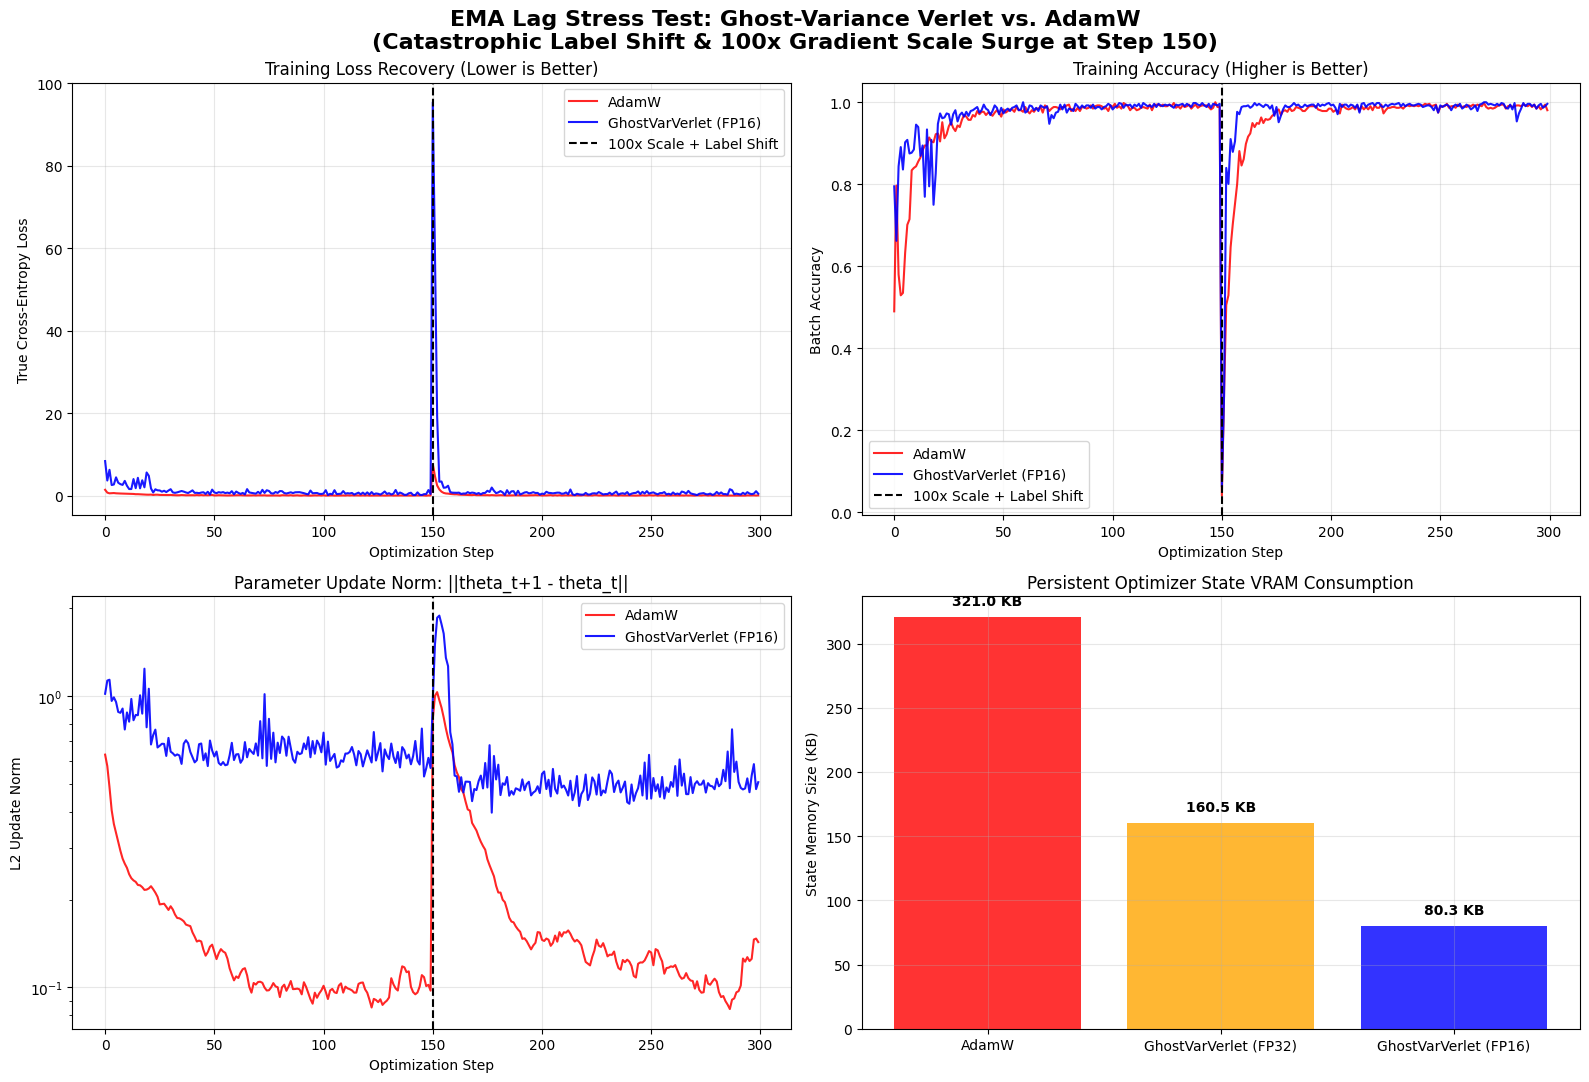

In [ ]:
# ==============================================================================
# Ghost-Variance Verlet vs. AdamW "EMA Lag" Stress Test
# ==============================================================================

import torch
import torch.nn as nn
from torch.optim import Optimizer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Ensure reproducible runs
torch.manual_seed(42)
np.random.seed(42)

# ==============================================================================
# 1. OPTIMIZER IMPLEMENTATION: Ghost-Variance Verlet
# ==============================================================================

class GhostVarVerlet(Optimizer):
    """
    Ghost-Variance Verlet (GVV) Optimizer.

    A memory-efficient, adaptive optimizer that replaces AdamW's persistent first-
    and second-moment buffers with:
      1. A same-step ghost microbatch variance estimate (for instant adaptivity).
      2. A single compressed (FP16 or FP32) previous-displacement buffer (for inertia).
      3. A reliability-gated momentum coefficient that suppresses low-SNR updates.
    """
    def __init__(self, params, lr=1e-3, beta_max=0.9, weight_decay=1e-2,
                 eps_abs=1e-8, eps_rel=1e-4, compress_state=True):
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= beta_max < 1.0:
            raise ValueError(f"Invalid beta_max: {beta_max}")

        defaults = dict(lr=lr, beta_max=beta_max, weight_decay=weight_decay,
                        eps_abs=eps_abs, eps_rel=eps_rel, compress_state=compress_state)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            beta_max = group['beta_max']
            wd = group['weight_decay']
            eps_abs = group['eps_abs']
            eps_rel = group['eps_rel']
            compress_state = group['compress_state']

            for p in group['params']:
                if p.grad is None:
                    continue

                G = p.grad

                # Retrieve or fall back if ghost microbatch gradients are missing
                if not hasattr(p, 'ghost_grads') or len(p.ghost_grads) < 2:
                    N = torch.zeros_like(G)
                else:
                    # Compute sample variance from ghost gradients (scaled by K)
                    stacked = torch.stack(p.ghost_grads)  # Shape: [K, *param_shape]
                    V_prime = torch.var(stacked, dim=0, unbiased=True)
                    K = len(p.ghost_grads)
                    N = K * V_prime

                # 1. Coordinate-wise Stabilizing Floor (scales with Gradient RMS)
                rms_G = torch.sqrt(torch.mean(G ** 2))
                eps_l = eps_abs + eps_rel * rms_G

                # 2. Ghost-SNR Force Calculation
                denom = torch.sqrt(G**2 + N + eps_l**2)
                F = G / denom

                # 3. Layerwise Gradient Reliability (R)
                mean_G2 = torch.mean(G**2)
                mean_denom2 = torch.mean(G**2 + N + eps_l**2)
                R = mean_G2 / (mean_denom2 + 1e-12)
                R = torch.clamp(R, 0.0, 1.0)

                # 4. Gated Momentum Coefficient
                mu_t = beta_max * R

                state = self.state[p]
                # Lazy initialization of displacement state
                if len(state) == 0:
                    if compress_state:
                        state['displacement'] = torch.zeros_like(p, dtype=torch.float16)
                    else:
                        state['displacement'] = torch.zeros_like(p, dtype=torch.float32)

                # Decompress displacement
                Delta = state['displacement'].to(p.dtype)

                # 5. Proposed Verlet Displacement
                U = mu_t * Delta - lr * F

                # 6. Decoupled Weight Decay
                if wd != 0:
                    p.mul_(1.0 - lr * wd)

                # 7. Parameter Update
                p.add_(U)

                # 8. Save/Compress state
                if compress_state:
                    state['displacement'].copy_(U.to(torch.float16))
                else:
                    state['displacement'].copy_(U)

                # Clear temporary ghost gradients to release memory
                if hasattr(p, 'ghost_grads'):
                    del p.ghost_grads

        return loss

# ==============================================================================
# 2. HELPER TO CALC STATE MEMORY OCCUPATION
# ==============================================================================

def get_optimizer_memory_kb(optimizer):
    """Calculates active optimizer state memory footprint in Kilobytes."""
    total_bytes = 0
    for group in optimizer.param_groups:
        for p in group['params']:
            state = optimizer.state.get(p, {})
            for k, v in state.items():
                if torch.is_tensor(v):
                    total_bytes += v.nelement() * v.element_size()
    return total_bytes / 1024.0

# ==============================================================================
# 3. HIGH BUDGET EXPERIMENT SETUP: EMA LAG STRESS TEST
# ==============================================================================

# Create synthetic dataset
X_np, y_np = make_classification(
    n_samples=25000, n_features=30, n_informative=25, n_classes=2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

# Convert to Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

def build_network():
    """Generates a standard 3-layer MLP classifier."""
    return nn.Sequential(
        nn.Linear(30, 256),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 2)
    )

def run_stress_test(opt_name, num_steps=300, batch_size=512, K=8):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n--- Running Experiment with: {opt_name} on {device} ---")

    model = build_network().to(device)

    lr = 0.005
    weight_decay = 0.01

    if opt_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "GhostVarVerlet (Compressed FP16)":
        optimizer = GhostVarVerlet(model.parameters(), lr=lr, weight_decay=weight_decay, compress_state=True)
    elif opt_name == "GhostVarVerlet (Uncompressed FP32)":
        optimizer = GhostVarVerlet(model.parameters(), lr=lr, weight_decay=weight_decay, compress_state=False)
    else:
        raise ValueError("Unknown Optimizer")

    history = {
        'step': [], 'loss': [], 'accuracy': [], 'update_norm': [], 'grad_norm': [], 'mem_kb': 0.0
    }

    criterion = nn.CrossEntropyLoss()
    dataset_size = len(X_train_t)

    # Run a warm-up forward-backward pass to initialize AdamW states
    x_warm = X_train_t[:batch_size].to(device)
    y_warm = y_train_t[:batch_size].to(device)
    optimizer.zero_grad()
    loss_warm = criterion(model(x_warm), y_warm)
    loss_warm.backward()
    optimizer.step()
    optimizer.zero_grad()

    for step in range(num_steps):
        # Sample mini-batch
        idx = np.random.choice(dataset_size, batch_size, replace=False)
        x_batch = X_train_t[idx].to(device)
        y_batch = y_train_t[idx].to(device)

        # ----------------------------------------------------------------------
        # THE EMA LAG TEST SHIFT: Mid-training disruption
        # ----------------------------------------------------------------------
        is_shifted = (step >= num_steps // 2)
        loss_scale = 100.0 if is_shifted else 1.0

        if is_shifted:
            y_batch = 1 - y_batch  # Target inversion

        # Clone current parameters for calculating step changes
        params_before = [p.clone() for p in model.parameters() if p.requires_grad]

        if "GhostVarVerlet" in opt_name:
            optimizer.zero_grad()
            for p in model.parameters():
                if p.requires_grad:
                    p.ghost_grads = []

            micro_size = batch_size // K
            total_loss_val = 0.0

            for k in range(K):
                start_idx = k * micro_size
                end_idx = start_idx + micro_size
                x_micro = x_batch[start_idx:end_idx]
                y_micro = y_batch[start_idx:end_idx]

                outputs = model(x_micro)
                loss_micro = (criterion(outputs, y_micro) * loss_scale) / K
                total_loss_val += loss_micro.item() * K
                loss_micro.backward()

                for p in model.parameters():
                    if p.requires_grad:
                        p.ghost_grads.append(p.grad.clone())

                optimizer.zero_grad()

            # Reconstruct the aggregated gradient
            for p in model.parameters():
                if p.requires_grad:
                    p.grad = torch.sum(torch.stack(p.ghost_grads), dim=0)

            grad_norm = torch.sqrt(sum(torch.sum(p.grad**2) for p in model.parameters() if p.grad is not None))
            optimizer.step()

        else:
            # Standard AdamW execution
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss_val = criterion(outputs, y_batch) * loss_scale
            total_loss_val = loss_val.item()
            loss_val.backward()

            grad_norm = torch.sqrt(sum(torch.sum(p.grad**2) for p in model.parameters() if p.grad is not None))
            optimizer.step()

        # Calculate true Parameter Update Norm: ||theta_new - theta_old||
        with torch.no_grad():
            idx_p = 0
            step_norm = 0.0
            for p in model.parameters():
                if p.requires_grad:
                    step_norm += torch.norm(p - params_before[idx_p]).item() ** 2
                    idx_p += 1
            step_norm = np.sqrt(step_norm)

        # Log training accuracy
        with torch.no_grad():
            model.eval()
            test_logits = model(x_batch)
            preds = torch.argmax(test_logits, dim=1)
            acc = (preds == y_batch).float().mean().item()
            model.train()

        history['step'].append(step)
        history['loss'].append(total_loss_val / loss_scale)
        history['accuracy'].append(acc)
        history['update_norm'].append(step_norm)
        history['grad_norm'].append(grad_norm.item())

        if step % 30 == 0 or step == num_steps - 1:
            print(f"  Step {step:03d} | Loss: {total_loss_val/loss_scale:.4f} | Acc: {acc:.3f} | Step Norm: {step_norm:.4f}")

    # Track VRAM footprint of optimizer
    history['mem_kb'] = get_optimizer_memory_kb(optimizer)
    print(f"==> Optimizer memory state size: {history['mem_kb']:.2f} KB")

    return history

# Run both optimizers
adamw_history = run_stress_test("AdamW")
gvv_compressed_history = run_stress_test("GhostVarVerlet (Compressed FP16)")
gvv_fp32_history = run_stress_test("GhostVarVerlet (Uncompressed FP32)")

# ==============================================================================
# 4. SCIENTIFIC VISUALIZATION & ANALYSIS ("THE HERO PLOT")
# ==============================================================================

fig, axs = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("EMA Lag Stress Test: Ghost-Variance Verlet vs. AdamW\n(Catastrophic Label Shift & 100x Gradient Scale Surge at Step 150)", fontsize=16, fontweight='bold')

# --- Plot 1: Unscaled Underlying Loss ---
axs[0, 0].plot(adamw_history['step'], adamw_history['loss'], label='AdamW', color='red', alpha=0.85)
axs[0, 0].plot(gvv_compressed_history['step'], gvv_compressed_history['loss'], label='GhostVarVerlet (FP16)', color='blue', alpha=0.9)
axs[0, 0].axvline(x=150, color='black', linestyle='--', label='100x Scale + Label Shift')
axs[0, 0].set_title("Training Loss Recovery (Lower is Better)")
axs[0, 0].set_xlabel("Optimization Step")
axs[0, 0].set_ylabel("True Cross-Entropy Loss")
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

# --- Plot 2: Accuracy Over Steps ---
axs[0, 1].plot(adamw_history['step'], adamw_history['accuracy'], label='AdamW', color='red', alpha=0.85)
axs[0, 1].plot(gvv_compressed_history['step'], gvv_compressed_history['accuracy'], label='GhostVarVerlet (FP16)', color='blue', alpha=0.9)
axs[0, 1].axvline(x=150, color='black', linestyle='--', label='100x Scale + Label Shift')
axs[0, 1].set_title("Training Accuracy (Higher is Better)")
axs[0, 1].set_xlabel("Optimization Step")
axs[0, 1].set_ylabel("Batch Accuracy")
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].legend()

# --- Plot 3: Param Update Norms (Destabilization tracker) ---
axs[1, 0].plot(adamw_history['step'], adamw_history['update_norm'], label='AdamW', color='red', alpha=0.85)
axs[1, 0].plot(gvv_compressed_history['step'], gvv_compressed_history['update_norm'], label='GhostVarVerlet (FP16)', color='blue', alpha=0.9)
axs[1, 0].axvline(x=150, color='black', linestyle='--')
axs[1, 0].set_title("Parameter Update Norm: ||theta_t+1 - theta_t||")
axs[1, 0].set_xlabel("Optimization Step")
axs[1, 0].set_ylabel("L2 Update Norm")
axs[1, 0].set_yscale('log')
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

# --- Plot 4: Persistent Optimizer Memory Consumption ---
opts = ['AdamW', 'GhostVarVerlet (FP32)', 'GhostVarVerlet (FP16)']
memories = [adamw_history['mem_kb'], gvv_fp32_history['mem_kb'], gvv_compressed_history['mem_kb']]
bars = axs[1, 1].bar(opts, memories, color=['red', 'orange', 'blue'], alpha=0.8)
axs[1, 1].set_title("Persistent Optimizer State VRAM Consumption")
axs[1, 1].set_ylabel("State Memory Size (KB)")
axs[1, 1].grid(True, alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    axs[1, 1].text(bar.get_x() + bar.get_width()/2.0, yval + (max(memories)*0.02), f"{yval:.1f} KB", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()